# Pertemuan 11
# Unsupervised Learning: Clustering

**Nama :** Alini Syawalia Riski Fenanda

**NIM :** 240401010213

**Mata Kuliah :** Data Science

# Tujuan Praktikum

Pada praktikum ini dilakukan segmentasi pelanggan menggunakan algoritma K-Means Clustering. Selain itu, dilakukan penentuan jumlah cluster menggunakan Metode Elbow, evaluasi menggunakan Silhouette Score, visualisasi hasil clustering, serta perbandingan dengan Hierarchical Clustering.

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

from scipy.cluster.hierarchy import dendrogram, linkage

# Langkah 1 - Generate dan Eksplorasi Dataset

In [2]:
np.random.seed(42)

grp1 = np.random.normal(
    [30,20],
    [6,8],
    (100,2)
)

grp2 = np.random.normal(
    [70,55],
    [8,10],
    (100,2)
)

grp3 = np.random.normal(
    [110,85],
    [10,8],
    (100,2)
)

data = np.vstack([
    grp1,
    grp2,
    grp3
])

df = pd.DataFrame(
    data,
    columns=[
        "pendapatan_tahunan",
        "skor_belanja"
    ]
)

df["usia"] = np.random.randint(
    18,
    65,
    len(df)
)

df["gender"] = np.random.choice(
    ["L","P"],
    len(df)
)

## Melihat Ukuran Dataset

In [3]:
print("Shape Dataset :")

print(df.shape)

Shape Dataset :
(300, 4)


## Statistik Dataset

In [4]:
df.describe().round(2)

,pendapatan_tahunan,skor_belanja,usia
count,300.00,300.00,300.00
mean,69.96,53.23,42.07
std,33.82,27.41,13.59
min,14.28,4.10,18.00
25%,32.14,25.60,30.00
50%,70.84,55.11,43.00
75%,103.40,78.16,53.00
max,140.79,103.17,64.00


## Lima Data Pertama

In [5]:
df.head()

,pendapatan_tahunan,skor_belanja,usia,gender
0,32.980285,18.893886,64,P
1,33.886131,32.184239,21,P
2,28.595080,18.126904,29,L
3,39.475277,26.139478,62,L
4,27.183154,24.340480,19,L


## Visualisasi Sebaran Data

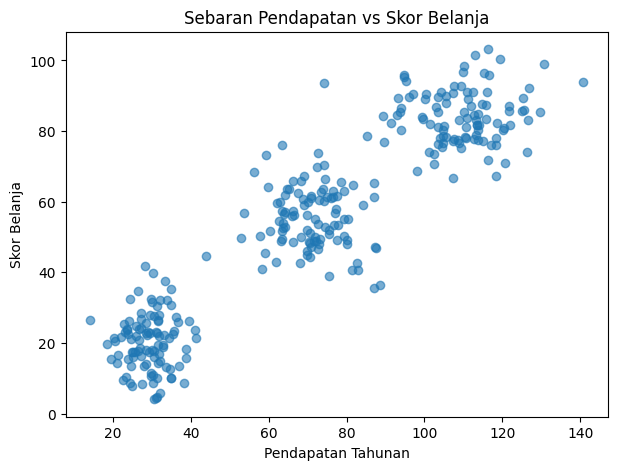

In [6]:
plt.figure(figsize=(7,5))

plt.scatter(
    df["pendapatan_tahunan"],
    df["skor_belanja"],
    alpha=0.6
)

plt.xlabel("Pendapatan Tahunan")

plt.ylabel("Skor Belanja")

plt.title("Sebaran Pendapatan vs Skor Belanja")

plt.show()

### Interpretasi

Berdasarkan scatter plot terlihat terdapat beberapa kelompok pelanggan yang mulai terbentuk berdasarkan pendapatan tahunan dan skor belanja. Hal ini menunjukkan bahwa data memiliki potensi untuk dilakukan proses clustering menggunakan algoritma K-Means.

# Langkah 2 - Preprocessing Data

In [7]:
X = df[
    [
        "pendapatan_tahunan",
        "skor_belanja"
    ]
].values

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [8]:
print("Rata-rata setelah scaling")

print(X_scaled.mean(axis=0).round(3))

print()

print("Standar deviasi setelah scaling")

print(X_scaled.std(axis=0).round(3))

Rata-rata setelah scaling
[-0.  0.]

Standar deviasi setelah scaling
[1. 1.]


### Interpretasi

Setelah proses StandardScaler, rata-rata setiap fitur mendekati 0 dan standar deviasi mendekati 1 sehingga setiap fitur memiliki skala yang sama dan tidak saling mendominasi.

# Langkah 3 - Menentukan Jumlah Cluster (Metode Elbow)

In [9]:
wcss = []

for k in range(1,11):

    km = KMeans(
        n_clusters=k,
        random_state=42,
        init="k-means++"
    )

    km.fit(X_scaled)

    wcss.append(km.inertia_)

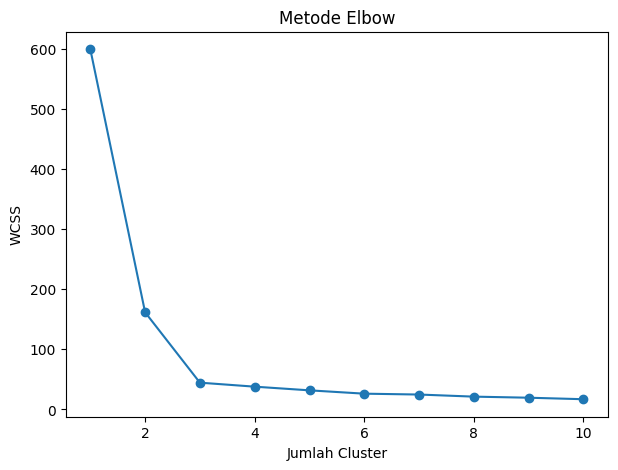

In [10]:
plt.figure(figsize=(7,5))

plt.plot(
    range(1,11),
    wcss,
    marker="o"
)

plt.xlabel("Jumlah Cluster")

plt.ylabel("WCSS")

plt.title("Metode Elbow")

plt.show()

### Interpretasi

Berdasarkan grafik Elbow, kurva mulai melandai pada **K = 3**. Hal tersebut menunjukkan bahwa jumlah cluster optimal adalah tiga kelompok. Hasil ini sesuai dengan dataset sintetis yang memang dibentuk dari tiga kelompok pelanggan berbeda.

# Langkah 4 - Melatih Model K-Means

In [11]:
model = KMeans(
    n_clusters=3,
    random_state=42,
    init="k-means++"
)

model.fit(X_scaled)

df["cluster"] = model.labels_

In [12]:
print("WCSS Akhir :")

print(model.inertia_)

print()

print("Silhouette Score :")

print(
    silhouette_score(
        X_scaled,
        model.labels_
    )
)

WCSS Akhir :
44.5564179805733

Silhouette Score :
0.6953274658286891


In [13]:
df.groupby("cluster")[
    [
        "pendapatan_tahunan",
        "skor_belanja"
    ]
].mean().round(2)

,pendapatan_tahunan,skor_belanja
cluster,,
0,70.99,55.05
1,29.31,20.27
2,109.20,84.08


### Interpretasi

Nilai Silhouette Score menunjukkan kualitas clustering yang baik karena setiap cluster memiliki jarak yang cukup jauh satu sama lain. Nilai rata-rata setiap cluster menunjukkan adanya perbedaan karakteristik pelanggan berdasarkan pendapatan dan perilaku belanja.

# Langkah 5 - Visualisasi Hasil Clustering

In [ ]:
centroids = scaler.inverse_transform(
    model.cluster_centers_
)

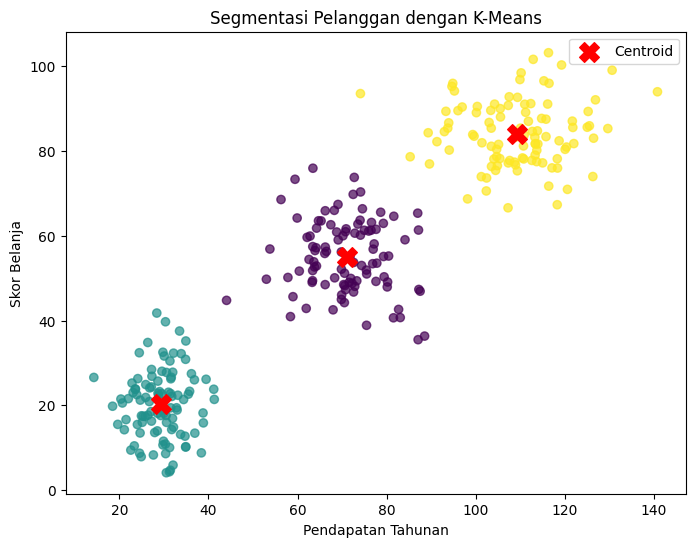

In [15]:
# Mengambil posisi centroid
centroids = scaler.inverse_transform(model.cluster_centers_)

plt.figure(figsize=(8,6))

plt.scatter(
    df["pendapatan_tahunan"],
    df["skor_belanja"],
    c=df["cluster"],
    cmap="viridis",
    alpha=0.7
)

plt.scatter(
    centroids[:,0],
    centroids[:,1],
    c="red",
    marker="X",
    s=200,
    label="Centroid"
)

plt.xlabel("Pendapatan Tahunan")
plt.ylabel("Skor Belanja")
plt.title("Segmentasi Pelanggan dengan K-Means")
plt.legend()

plt.show()

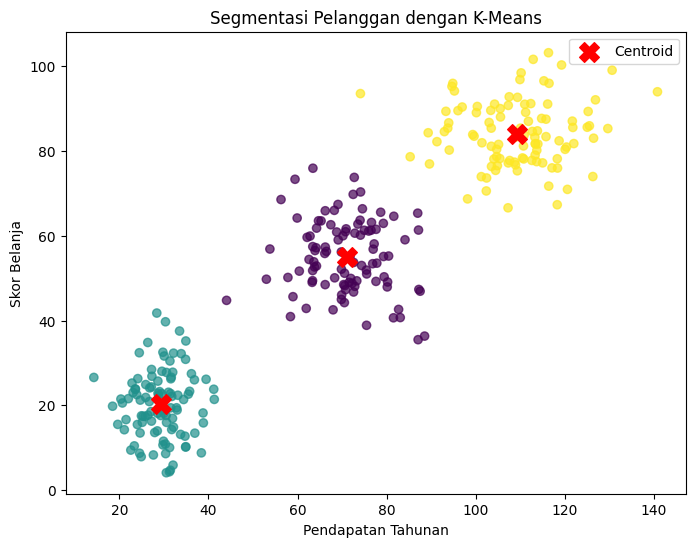

In [16]:
plt.figure(figsize=(8,6))

plt.scatter(
    df["pendapatan_tahunan"],
    df["skor_belanja"],
    c=df["cluster"],
    cmap="viridis",
    alpha=0.7
)

plt.scatter(
    centroids[:,0],
    centroids[:,1],
    c="red",
    marker="X",
    s=200,
    label="Centroid"
)

plt.xlabel("Pendapatan Tahunan")

plt.ylabel("Skor Belanja")

plt.title("Segmentasi Pelanggan dengan K-Means")

plt.legend()

plt.show()

### Interpretasi Cluster

**Cluster 0**

Pelanggan dengan pendapatan rendah dan skor belanja rendah sehingga termasuk segmen **Hemat**.

**Cluster 1**

Pelanggan dengan pendapatan menengah dan skor belanja menengah sehingga termasuk segmen **Menengah**.

**Cluster 2**

Pelanggan dengan pendapatan tinggi dan skor belanja tinggi sehingga termasuk segmen **Premium/Boros**.

# Langkah 6 - Hierarchical Clustering

In [17]:
Z = linkage(
    X_scaled,
    method="ward"
)

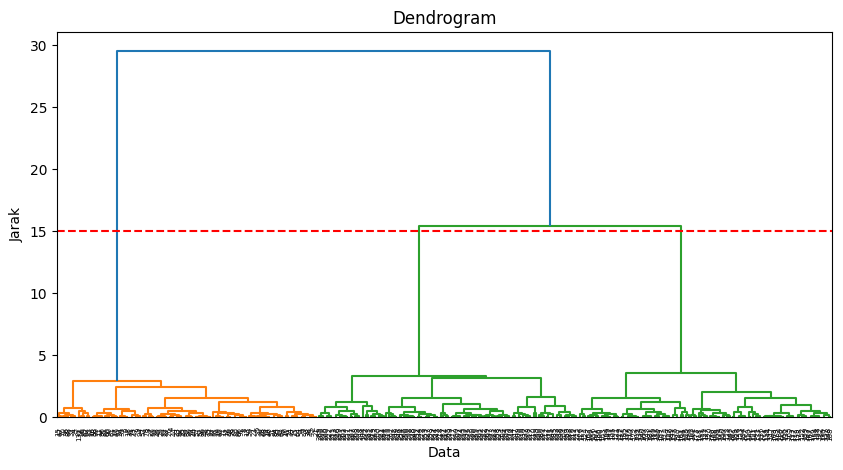

In [18]:
plt.figure(figsize=(10,5))

dendrogram(Z)

plt.axhline(
    y=15,
    color="red",
    linestyle="--"
)

plt.title("Dendrogram")

plt.xlabel("Data")

plt.ylabel("Jarak")

plt.show()

### Interpretasi

Dari dendrogram terlihat bahwa pemotongan pada garis horizontal menghasilkan sekitar tiga cluster. Hasil ini konsisten dengan metode Elbow dan model K-Means sehingga menunjukkan bahwa segmentasi pelanggan yang diperoleh cukup stabil dan sesuai dengan struktur data.

# Kesimpulan

Pada praktikum ini berhasil dilakukan segmentasi pelanggan menggunakan algoritma K-Means Clustering. Berdasarkan Metode Elbow diperoleh jumlah cluster optimal sebanyak tiga cluster. Nilai Silhouette Score menunjukkan bahwa hasil clustering memiliki kualitas yang baik. Selain itu, hasil Hierarchical Clustering juga menghasilkan jumlah cluster yang konsisten sehingga memperkuat hasil segmentasi pelanggan menjadi tiga kelompok utama, yaitu pelanggan hemat, pelanggan menengah, dan pelanggan premium.